In [1]:
# =============================================================================
# 1. SETUP & IMPORTS
# =============================================================================
!pip install radon asttokens Levenshtein transformers torch torchvision torchaudio tensorflow pandas numpy scikit-learn matplotlib seaborn gdown pydrive

import os
import re
import ast
import time
import pickle
import warnings
import itertools
import difflib
import tokenize
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein

import torch
import torch.nn.functional as F
import tensorflow as tf
from transformers import AutoTokenizer, AutoModel
from radon.complexity import cc_visit
from scipy.spatial.distance import jensenshannon

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

# Suppress runtime warnings for division by zero during matrix comparisons
warnings.filterwarnings("ignore", category=RuntimeWarning, module="scipy.spatial.distance")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.6 MB/s eta 0:00:00
  Created wheel for pydrive: filename=PyDrive-1.3.1-py3-none-any.whl size=27433 sha256=31325fd09ee2e75ea9cc12ff7a22d5495cc3a0c9c6eec910e980e12d18193054
  Stored in directory: /root/.cache/pip/wheels/6c/10/da/a5b513f5b3916fc391c20ee7b4633e5cf3396d570cdd74970f
Successfully built pydrive


2026-04-30 22:13:18.736196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777587198.934869      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777587198.993479      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777587199.473195      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777587199.473237      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777587199.473240      24 computation_placer.cc:177] computation placer alr

In [2]:
# =============================================================================
# 2. GLOBAL CONFIGURATIONS & MODELS
# =============================================================================
# Load GraphCodeBERT to act as the MRT encoder
print("Loading graphCodeBERT models...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
mrt_model = AutoModel.from_pretrained("microsoft/graphcodebert-base").to(device)

Loading graphCodeBERT models...
Using device: cuda


config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
def extract_data_flow_variables(filepath):
    """Extracts a list of UNIQUE variable names from the code."""
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            code = f.read()
        tree = ast.parse(code)

        variables = []

        class DFVisitor(ast.NodeVisitor):
            def visit_Assign(self, node):
                for target in node.targets:
                    if isinstance(target, ast.Name):
                        variables.append(target.id)
                self.generic_visit(node)

        DFVisitor().visit(tree)
        return code, list(set(variables))
    except Exception:
        return "", []

In [4]:
# =============================================================================
# 3. OAST CREATION
# =============================================================================
class PrunedOASTBuilder(ast.NodeVisitor):
    def __init__(self):
        self.pre_order = []
        self.post_order = []

    def visit_For(self, node):
        self.pre_order.append("LoopNode")
        self.generic_visit(node)
        self.post_order.append("LoopNode")

    def visit_While(self, node):
        self.pre_order.append("LoopNode")
        self.generic_visit(node)
        self.post_order.append("LoopNode")

    def visit_If(self, node):
        self.pre_order.append("BranchNode")
        self.generic_visit(node)
        self.post_order.append("BranchNode")

    def visit_Import(self, node):
        pass

    def visit_ImportFrom(self, node):
        pass

    def visit_Pass(self, node):
        pass

    def generic_visit(self, node):
        node_type = type(node).__name__
        redundant_nodes = {"Module", "Load", "Store", "Del", "Expr", "alias"}

        if node_type not in redundant_nodes:
            self.pre_order.append(node_type)
            super().generic_visit(node)
            self.post_order.append(node_type)
        else:
            super().generic_visit(node)

def get_oast_sequences(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            code = f.read()
        tree = ast.parse(code)
        builder = PrunedOASTBuilder()
        builder.visit(tree)
        return " ".join(builder.pre_order), " ".join(builder.post_order)
    except Exception:
        return "", ""

def get_mrt_oast_embedding(filepath):
    pre_seq, post_seq = get_oast_sequences(filepath)
    if not pre_seq:
        return torch.zeros((1, 768)).to(device)

    pre_inputs = tokenizer(pre_seq, return_tensors="pt", truncation=True, max_length=256).to(device)
    post_inputs = tokenizer(post_seq, return_tensors="pt", truncation=True, max_length=256).to(device)

    with torch.no_grad():
        pre_emb = mrt_model(**pre_inputs).last_hidden_state[:, 0, :]
        post_emb = mrt_model(**post_inputs).last_hidden_state[:, 0, :]

    fused_embedding = (pre_emb + post_emb) / 2.0
    return fused_embedding
    
def get_mrt_oast_cosine_similarity(filepath1, filepath2):
    emb1 = get_mrt_oast_embedding(filepath1)
    emb2 = get_mrt_oast_embedding(filepath2)
    sim = F.cosine_similarity(emb1, emb2)
    return sim.item()

In [5]:
# =============================================================================
# 4. FEATURE EXTRACTION FUNCTIONS
# =============================================================================
def get_file_length(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return len(f.readlines())
    except Exception:
        return 0

class CodeAnalyzer(ast.NodeVisitor):
    def __init__(self):
        self.function_count = 0
        self.variable_names = set()

    def visit_FunctionDef(self, node):
        self.function_count += 1
        self.generic_visit(node)

    def visit_Assign(self, node):
        for target in node.targets:
            if isinstance(target, ast.Name):
                self.variable_names.add(target.id)
            elif isinstance(target, (ast.Tuple, ast.List)):
                for elt in target.elts:
                    if isinstance(elt, ast.Name):
                        self.variable_names.add(elt.id)
        self.generic_visit(node)

def analyze_code_structure(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            tree = ast.parse(f.read(), filename=filepath)
        analyzer = CodeAnalyzer()
        analyzer.visit(tree)
        return analyzer.function_count, len(analyzer.variable_names)
    except Exception:
        return 0, 0

def get_ast_tree(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return ast.parse(f.read())
    except Exception:
        return None

def get_cyclomatic_complexity(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            code = f.read()
        complexity_scores = cc_visit(code)
        return sum(c.complexity for c in complexity_scores)
    except Exception:
        return 0

def calculate_comment_ratio(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            code = f.read()
        total_lines = len(code.splitlines())
        comment_lines = sum(1 for line in code.splitlines() if line.strip().startswith('#'))
        if total_lines == 0:
            return 0
        return comment_lines / total_lines
    except Exception:
        return 0

class ASTTransitionExtractor:
    def __init__(self, tree):
        self.tree = tree

    def get_sequential_transitions(self):
        sequence = []
        class DFSVisitor(ast.NodeVisitor):
            def generic_visit(self, node):
                sequence.append(type(node).__name__)
                super().generic_visit(node)
        visitor = DFSVisitor()
        visitor.visit(self.tree)
        return list(zip(sequence[:-1], sequence[1:]))

def build_transition_matrix(transitions, normalize=False):
    counts = Counter(transitions)
    unique_tokens = sorted(list(set([t[0] for t in transitions] + [t[1] for t in transitions])))
    df = pd.DataFrame(0.0 if normalize else 0, index=unique_tokens, columns=unique_tokens)
    for (src, dst), count in counts.items():
        df.at[src, dst] = count
    if normalize:
        df = df.div(df.sum(axis=1), axis=0).fillna(0)
    return df

def extract_ast_sequence_string(parsed_ast):
    sequence = []
    class DFSVisitor(ast.NodeVisitor):
        def generic_visit(self, node):
            sequence.append(type(node).__name__)
            super().generic_visit(node)
    visitor = DFSVisitor()
    visitor.visit(parsed_ast)
    return " ".join(sequence)

def get_ast_cosine_similarity(tree1, tree2):
    str1 = extract_ast_sequence_string(tree1)
    str2 = extract_ast_sequence_string(tree2)
    vectorizer = TfidfVectorizer(ngram_range=(1, 3), lowercase=False)
    try:
        tfidf_matrix = vectorizer.fit_transform([str1, str2])
        cos_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
        return np.clip(cos_sim, 0.0, 1.0)
    except Exception:
        return 0.0

def calculate_percentage_diff(val1, val2):
    if val1 == 0 and val2 == 0:
        return 0.0
    return abs(val1 - val2) / max(val1, val2)

def get_levenshtein_similarity(filepath1, filepath2):
    try:
        with open(filepath1, 'r', encoding='utf-8') as f1, open(filepath2, 'r', encoding='utf-8') as f2:
            return Levenshtein.ratio(f1.read(), f2.read())
    except Exception:
        return 0.0

def get_token_similarity(filepath1, filepath2):
    try:
        with open(filepath1, 'rb') as f1, open(filepath2, 'rb') as f2:
            tokens1 = set([tok.string for tok in tokenize.tokenize(f1.readline) if tok.type == tokenize.NAME])
            tokens2 = set([tok.string for tok in tokenize.tokenize(f2.readline) if tok.type == tokenize.NAME])

            if not tokens1 or not tokens2:
                return 0.0
            return len(tokens1 & tokens2) / len(tokens1 | tokens2)
    except Exception:
        return 0.0

In [6]:
def calculate_pair_features(file1_path, file2_path):
    tree1 = get_ast_tree(file1_path)
    tree2 = get_ast_tree(file2_path)
    ast_cos_sim = get_ast_cosine_similarity(tree1, tree2) if tree1 and tree2 else 0.0

    cc1, cc2 = get_cyclomatic_complexity(file1_path), get_cyclomatic_complexity(file2_path)
    cr1, cr2 = calculate_comment_ratio(file1_path), calculate_comment_ratio(file2_path)
    len1, len2 = get_file_length(file1_path), get_file_length(file2_path)
    func_count1, var_count1 = analyze_code_structure(file1_path)
    func_count2, var_count2 = analyze_code_structure(file2_path)

    return {
        'File_1_Path': file1_path,
        'File_2_Path': file2_path,
        'Token Similarity': get_token_similarity(file1_path, file2_path),
        'Levenshtein Similarity': get_levenshtein_similarity(file1_path, file2_path),
        'ast_cosine_similarity': ast_cos_sim,
        'length_file_diff': calculate_percentage_diff(len1, len2),
        'function_count_diff': calculate_percentage_diff(func_count1, func_count2),
        'variable_count_diff': calculate_percentage_diff(var_count1, var_count2),
        'cyclomatic_complexity_diff': calculate_percentage_diff(cc1, cc2),
        'comment_ratio_diff': calculate_percentage_diff(cr1, cr2),
        'mrt_oast_cosine_similarity': get_mrt_oast_cosine_similarity(file1_path, file2_path)
    }

In [7]:
# =============================================================================
# 5. DATA LOADING
# =============================================================================
print("Downloading datasets...")
os.system('gdown "15QhVY6T61mGWpXvuyBr65v3GCCvigdvB" -O downloaded_file.zip')
os.system('unzip -qo downloaded_file.zip -d ./')

csv_plagiarism = './PythonDataSet/cheating_dataset.csv'
csv_plagiarism_features = './PythonDataSet/cheating_features_dataset.csv'
code_dir = 'PythonDataSet/'

try:
    df_plagiarism = pd.read_csv(csv_plagiarism)
    df_features = pd.read_csv(csv_plagiarism_features)
    print('Base Features loaded successfully.')
except FileNotFoundError:
    print('Could not find the dataset CSVs. Ensure data is downloaded.')
    df_plagiarism = pd.DataFrame() # Placeholder

ai_models = ['gemini', 'mistral', 'deepseek']
base_ai_dir = "ai_modified_code/"
new_rows = []

if os.path.exists(base_ai_dir) and not df_plagiarism.empty:
    for root, dirs, files in os.walk(base_ai_dir):
        for filename in files:
            if filename.endswith('.py'):
                ai_label = next((model for model in ai_models if model in root.lower() or model in filename.lower()), 'unknown')
                match = re.search(r'(submission\d+\.py)', filename)
                if match:
                    new_rows.append({
                        'File_1': match.group(1),
                        'File_2': os.path.join(root, filename).replace('\\', '/'),
                        'Label': 1,
                        'AI_Model': ai_label
                    })

Base Features loaded successfully.


Downloading...
From: https://drive.google.com/uc?id=15QhVY6T61mGWpXvuyBr65v3GCCvigdvB
To: /kaggle/working/downloaded_file.zip
100%|██████████| 495k/495k [00:00<00:00, 106MB/s]


In [8]:
# =============================================================================
# 6. DATA BALANCING
# =============================================================================
if new_rows:
    df_ai_pairs = pd.DataFrame(new_rows)
    if 'AI_Model' not in df_plagiarism.columns:
        df_plagiarism['AI_Model'] = 'human'

    df_label_0 = df_plagiarism[df_plagiarism['Label'] == 0]
    df_label_1_human = df_plagiarism[df_plagiarism['Label'] == 1]

    count_0 = len(df_label_0)
    count_1_human = len(df_label_1_human)
    total_ai_needed = max(0, count_0 - count_1_human)

    if total_ai_needed > 0:
        per_model_needed = total_ai_needed // len(ai_models)
        available_counts = {model: len(df_ai_pairs[df_ai_pairs['AI_Model'] == model]) for model in ai_models}
        max_possible_per_model = min(available_counts.values()) if available_counts else 0
        take_per_model = min(per_model_needed, max_possible_per_model)

        sampled_ai_dfs = [df_ai_pairs[df_ai_pairs['AI_Model'] == model].sample(n=take_per_model, random_state=42) for model in ai_models]
        df_ai_balanced = pd.concat(sampled_ai_dfs, ignore_index=True)
        df_label_1_total = pd.concat([df_label_1_human, df_ai_balanced], ignore_index=True)

        if len(df_label_0) > len(df_label_1_total):
            df_label_0 = df_label_0.sample(n=len(df_label_1_total), random_state=42)
        elif len(df_label_1_total) > len(df_label_0):
            df_label_1_total = df_label_1_total.sample(n=len(df_label_0), random_state=42)
    else:
        df_label_1_total = df_label_1_human
        if len(df_label_1_total) > count_0:
            df_label_1_total = df_label_1_total.sample(n=count_0, random_state=42)

    df_plagiarism = pd.concat([df_label_0, df_label_1_total], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Successfully balanced the dataset. Total instances: {len(df_plagiarism)}")

Successfully balanced the dataset. Total instances: 386


In [9]:
# =============================================================================
# 7. FEATURE EXTRACTION LOOP
# =============================================================================
new_features = []
print(f"Calculating all features from scratch for {len(df_plagiarism)} instances...")

for index, row in df_plagiarism.iterrows():
    file1_path = os.path.join(code_dir, row['File_1'])
    file2_path = os.path.join(code_dir, row['File_2'])
    
    # Calculate base properties
    cc1, cc2 = get_cyclomatic_complexity(file1_path), get_cyclomatic_complexity(file2_path)
    cr1, cr2 = calculate_comment_ratio(file1_path), calculate_comment_ratio(file2_path)
    len1, len2 = get_file_length(file1_path), get_file_length(file2_path)
    func_count1, var_count1 = analyze_code_structure(file1_path)
    func_count2, var_count2 = analyze_code_structure(file2_path)
    tree1, tree2 = get_ast_tree(file1_path), get_ast_tree(file2_path)

    new_features.append({
        'Token Similarity': get_token_similarity(file1_path, file2_path),
        'Levenshtein Similarity': get_levenshtein_similarity(file1_path, file2_path),
        'Length File 1': len1,
        'Length File 2': len2,
        'Function Count File 1': func_count1,
        'Function Count File 2': func_count2,
        'Variable Count File 1': var_count1,
        'Variable Count File 2': var_count2,
        'Comment Ratio File 1': cr1,
        'Comment Ratio File 2': cr2,
        'Cyclomatic Complexity File 1': cc1,
        'Cyclomatic Complexity File 2': cc2,
        'ast_cosine_similarity': get_ast_cosine_similarity(tree1, tree2) if tree1 and tree2 else 0.0,
        'cyclomatic_complexity_diff': calculate_percentage_diff(cc1, cc2),
        'comment_ratio_diff': calculate_percentage_diff(cr1, cr2),
        'length_file_diff': calculate_percentage_diff(len1, len2),
        'function_count_diff': calculate_percentage_diff(func_count1, func_count2),
        'variable_count_diff': calculate_percentage_diff(var_count1, var_count2),
        'mrt_oast_cosine_similarity': get_mrt_oast_cosine_similarity(file1_path, file2_path)
    })

df_integrated_features = pd.DataFrame(new_features)
if not df_integrated_features.empty:
    df_integrated_features['Label'] = df_plagiarism['Label'].values
    if 'AI_Model' in df_plagiarism.columns:
        df_integrated_features['AI_Model'] = df_plagiarism['AI_Model'].values
        df_integrated_features['AI_Model_Numeric'] = df_integrated_features['AI_Model'].map({'human': 0, 'deepseek': 1, 'gemini': 2, 'mistral': 3})
    print("Integrated Features Shape:", df_integrated_features.shape)


Calculating all features from scratch for 386 instances...
Integrated Features Shape: (386, 22)


In [10]:
# =============================================================================
# 8. TRAIN-TEST SPLIT & SCALING
# =============================================================================
if not df_integrated_features.empty:
    relative_features = [
        'Token Similarity', 'Levenshtein Similarity', 'ast_cosine_similarity',
        'length_file_diff', 'function_count_diff', 'variable_count_diff', 
        'cyclomatic_complexity_diff', 'comment_ratio_diff', 'mrt_oast_cosine_similarity'
    ]
    features_to_use = [col for col in relative_features if col in df_integrated_features.columns]

    X = df_integrated_features[features_to_use]
    y = df_integrated_features['Label']

    x_train_raw, x_temp_raw, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42)
    features_test_raw, features_val_raw, resultado_test, resultado_val = train_test_split(x_temp_raw, y_temp, test_size=0.50, random_state=42)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train_raw)
    features_val = scaler.transform(features_val_raw)
    features_test = scaler.transform(features_test_raw)

    pca = PCA(n_components=2)
    componentes_principales_train = pca.fit_transform(x_train)

In [11]:
# =============================================================================
# 9. BENCHMARK: LOGISTIC REGRESSION
# =============================================================================
if 'x_train' in locals():
    logistic_model = LogisticRegression(random_state=42, max_iter=1000)
    logistic_model.fit(x_train, y_train)

    print("\n" + "="*60 + "\n              BENCHMARK: LOGISTIC REGRESSION\n" + "="*60)
    y_pred = logistic_model.predict(features_val)
    y_pred_prob = logistic_model.predict_proba(features_val)[:, 1]

    # print(f"Accuracy: {accuracy_score(resultado_val, y_pred):.4f}")
    print(f"AUC-ROC:  {roc_auc_score(resultado_val, y_pred_prob):.4f}\n")
    print(classification_report(resultado_val, y_pred, target_names=["No Plagio", "Plagio"]))


              BENCHMARK: LOGISTIC REGRESSION
AUC-ROC:  0.9079

              precision    recall  f1-score   support

   No Plagio       0.80      0.84      0.82        19
      Plagio       0.84      0.80      0.82        20

    accuracy                           0.82        39
   macro avg       0.82      0.82      0.82        39
weighted avg       0.82      0.82      0.82        39



In [12]:
import os
import shutil
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive

secrets_source = '/kaggle/input/datasets/flixrojas/drive-secrets/client_secrets.json'
creds_source = '/kaggle/input/datasets/flixrojas/credentials/mycreds.txt'

working_dir = '/kaggle/working/'
creds_working_path = os.path.join(working_dir, 'mycreds.txt')

if os.path.exists(creds_source):
    shutil.copy(creds_source, creds_working_path)
else:
    print(f"Error: Could not find credentials at {creds_source}")

gauth = GoogleAuth()

gauth.LoadClientConfigFile(secrets_source)
gauth.LoadCredentialsFile(creds_working_path)

if gauth.credentials is None:
    print("Credentials not found or invalid. Manual authentication required.")
    gauth.CommandLineAuth()
elif gauth.access_token_expired:
    print("Token expired. Refreshing automatically...")
    gauth.Refresh()
else:
    gauth.Authorize()

gauth.SaveCredentialsFile(creds_working_path)

drive = GoogleDrive(gauth)
print("Silent authentication successful.")

Token expired. Refreshing automatically...
Silent authentication successful.


In [13]:
import os
import pickle
import tensorflow as tf
from sklearn.metrics import classification_report, roc_auc_score

# =============================================================================
# 10. NEURAL NETWORK MODEL (MLP)
# =============================================================================
umbral = 0.8
working_dir = '/kaggle/working/'
folder_id = '1K6SLWRGAPlKiT0O6eV1B-PveEJQNlZgB'

# skip training if these exist
target_model_name = 'model_epoch_200.keras'
target_scaler_name = 'scaler.pkl'

class DriveUploadCallback(tf.keras.callbacks.Callback):
    def __init__(self, drive_client, folder_id, local_dir):
        super().__init__()
        self.drive_client = drive_client
        self.folder_id = folder_id
        self.local_dir = local_dir

    def on_epoch_end(self, epoch, logs=None):
        filename = f'model_epoch_{epoch + 1:02d}.keras'
        local_filepath = os.path.join(self.local_dir, filename)
        
        self.model.save(local_filepath)
        print(f"\nSaved locally: {local_filepath}")
        
        try:
            drive_file = self.drive_client.CreateFile({
                'title': filename,
                'parents': [{'id': self.folder_id}]
            })
            drive_file.SetContentFile(local_filepath)
            drive_file.Upload()
            print(f"Uploaded to Google Drive: {filename}")
        except Exception as e:
            print(f"Failed to upload {filename} to Google Drive. Error: {e}")

if 'x_train' in locals():
    # Query Google Drive 
    print("Checking Google Drive for existing model and scaler...")
    file_list = drive.ListFile({'q': f"'{folder_id}' in parents and trashed=false"}).GetList()
    
    model_file_id = None
    scaler_file_id = None
    
    for drive_file in file_list:
        if drive_file['title'] == target_model_name:
            model_file_id = drive_file['id']
        elif drive_file['title'] == target_scaler_name:
            scaler_file_id = drive_file['id']

    # 2. Conditional branch based on file existence
    if model_file_id and scaler_file_id:
        print(f"Found {target_model_name} and {target_scaler_name} in Google Drive. Downloading...")
        
        # Download and load scaler
        scaler_local_path = os.path.join(working_dir, target_scaler_name)
        downloaded_scaler = drive.CreateFile({'id': scaler_file_id})
        downloaded_scaler.GetContentFile(scaler_local_path)
        
        with open(scaler_local_path, 'rb') as f:
            scaler = pickle.load(f)
        print("Scaler successfully loaded from Drive.")
        
        # Download and load model
        model_local_path = os.path.join(working_dir, target_model_name)
        downloaded_model = drive.CreateFile({'id': model_file_id})
        downloaded_model.GetContentFile(model_local_path)
        
        model = tf.keras.models.load_model(model_local_path)
        print("Model successfully loaded from Drive.")
        
    else:
        print("Required files not found in Google Drive. Initiating training process...")
        
        if 'scaler' in locals():
            scaler_path = os.path.join(working_dir, 'scaler.pkl')
            with open(scaler_path, 'wb') as f:
                pickle.dump(scaler, f)
            
            try:
                drive_scaler = drive.CreateFile({
                    'title': 'scaler.pkl',
                    'parents': [{'id': folder_id}]
                })
                drive_scaler.SetContentFile(scaler_path)
                drive_scaler.Upload()
                print("Scaler uploaded to Google Drive.")
            except Exception as e:
                print(f"Failed to upload scaler: {e}")

        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(16, activation='relu', input_shape=(x_train.shape[1],), name="Entrada"),
            tf.keras.layers.Dense(16, activation='relu', name="Capa1"),
            tf.keras.layers.Dense(1, activation='sigmoid', name="Salida")
        ])

        model.compile(
            optimizer='adam', 
            loss='binary_crossentropy', 
            metrics=[tf.keras.metrics.Precision(name='precision_Plagio', thresholds=umbral)]
        )
        
        # Initialize custom callback
        drive_callback = DriveUploadCallback(drive, folder_id, working_dir)

        # Train the model
        history = model.fit(
            x_train, 
            y_train, 
            epochs=200, 
            batch_size=2048, 
            validation_data=(features_val, resultado_val), 
            callbacks=[drive_callback], 
            verbose=1
        )
    
    # 3. Evaluation (This runs whether the model was downloaded or freshly trained)
    print("\nPredicting on test features...")
    y_pred_prob_nn = model.predict(features_test)
    y_pred_nn = (y_pred_prob_nn > umbral).astype(int)
    
    print("\nNeural Network Evaluation:")
    print(classification_report(resultado_test, y_pred_nn, target_names=['Original - 0', 'Plagio - 1']))
    print(f"AUC-ROC Score: {roc_auc_score(resultado_test, y_pred_prob_nn):.4f}")

Checking Google Drive for existing model and scaler...
Required files not found in Google Drive. Initiating training process...
Scaler uploaded to Google Drive.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777587262.229828      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13193 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777587262.235042      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/200


I0000 00:00:1777587264.555361     617 service.cc:152] XLA service 0x7fc0f000aae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777587264.555415     617 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777587264.555421     617 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777587264.860391     617 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.6005 - precision_Plagio: 0.9701

I0000 00:00:1777587265.681882     617 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Saved locally: /kaggle/working/model_epoch_01.keras
Uploaded to Google Drive: model_epoch_01.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.6005 - precision_Plagio: 0.9701 - val_loss: 0.5433 - val_precision_Plagio: 1.0000
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5971 - precision_Plagio: 0.9701
Saved locally: /kaggle/working/model_epoch_02.keras
Uploaded to Google Drive: model_epoch_02.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.5971 - precision_Plagio: 0.9701 - val_loss: 0.5387 - val_precision_Plagio: 1.0000
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5938 - precision_Plagio: 0.9701
Saved locally: /kaggle/working/model_epoch_03.keras
Uploaded to Google Drive: model_epoch_03.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.5938 - precision_Plagio: 0.9701 - val_loss: 0.5344 - val_precision_Plagio: 1.0000
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5906 - precision_Plagio: 0.9701
Saved locally: /kaggle/working/model_epoch

In [14]:
import os
import itertools
import pandas as pd
import torch
import torch.nn.functional as F
import tensorflow as tf

# =============================================================================
# 11. FINAL VALIDATION
# =============================================================================

def build_final_validation_dataset(validation_dir):
    all_files = [os.path.join(root, file) for root, dirs, files in os.walk(validation_dir) for file in files if file.endswith('.py')]
    
    # 1. Precompute base features once per file to avoid redundant processing
    cache = precompute_file_features(all_files)
    
    # 2. Generate pairs
    pairs = list(itertools.combinations(all_files, 2))
    validation_features = []
    
    print(f"Calculating pair differentials for {len(pairs)} pairs...")
    
    for file1_path, file2_path in pairs:
        data1 = cache[file1_path]
        data2 = cache[file2_path]
        
        ast_cos_sim = get_ast_cosine_similarity(data1['tree'], data2['tree']) if data1['tree'] and data2['tree'] else 0.0
        mrt_sim = F.cosine_similarity(data1['embedding'], data2['embedding']).item()
        
        validation_features.append({
            'File_1_Path': file1_path,
            'File_2_Path': file2_path,
            'Token Similarity': get_token_similarity(file1_path, file2_path),
            'Levenshtein Similarity': get_levenshtein_similarity(file1_path, file2_path),
            'ast_cosine_similarity': ast_cos_sim,
            'length_file_diff': calculate_percentage_diff(data1['length'], data2['length']),
            'function_count_diff': calculate_percentage_diff(data1['func_var'][0], data2['func_var'][0]),
            'variable_count_diff': calculate_percentage_diff(data1['func_var'][1], data2['func_var'][1]),
            'cyclomatic_complexity_diff': calculate_percentage_diff(data1['cc'], data2['cc']),
            'comment_ratio_diff': calculate_percentage_diff(data1['cr'], data2['cr']),
            'mrt_oast_cosine_similarity': mrt_sim
        })

    return pd.DataFrame(validation_features)

def evaluate_validation_dataset(model_input, scaler, validation_df, umbral):
    model_obj = tf.keras.models.load_model(model_input) if isinstance(model_input, str) else model_input
    
    expected_features = list(scaler.feature_names_in_) if hasattr(scaler, 'feature_names_in_') else relative_features

    X_validation_scaled = scaler.transform(validation_df[expected_features].values)
    predictions_prob = model_obj.predict(X_validation_scaled)

    result_df = validation_df.copy()
    result_df['Plagiarism_Probability'] = predictions_prob
    result_df['Predicted_Class'] = (predictions_prob > umbral).astype(int)
    return result_df.sort_values(by='Plagiarism_Probability', ascending=False)

In [15]:
import os
import pickle
import tensorflow as tf

# =============================================================================
# 12. PREDICTION ON REAL DATA (LOADING SAVED MODEL & SCALER)
# =============================================================================

saved_model_path = '/kaggle/working/model_epoch_50.keras'
saved_scaler_path = '/kaggle/working/scaler.pkl'
validation_dir = "./final_validation_dataset"
umbral = 0.8

def precompute_file_features(all_files):
    """Calculates heavy base features exactly ONCE per file."""
    features_cache = {}
    total = len(all_files)
    
    for i, filepath in enumerate(all_files, 1):
        print(f"Precomputing features for file {i}/{total}...")
        
        # Calculate heavy features once
        tree = get_ast_tree(filepath)
        embedding = get_mrt_oast_embedding(filepath)
        
        features_cache[filepath] = {
            'tree': tree,
            'embedding': embedding,
            'cc': get_cyclomatic_complexity(filepath),
            'cr': calculate_comment_ratio(filepath),
            'length': get_file_length(filepath),
            'func_var': analyze_code_structure(filepath) # Returns (func_count, var_count)
        }
    return features_cache

if os.path.exists(validation_dir) and os.path.exists(saved_model_path) and os.path.exists(saved_scaler_path):
    
    print(f"Loading model from: {saved_model_path}")
    loaded_model = tf.keras.models.load_model(saved_model_path)
    
    print(f"Loading scaler from: {saved_scaler_path}")
    with open(saved_scaler_path, 'rb') as f:
        loaded_scaler = pickle.load(f)

    print("Building features for the final validation dataset...")
    df_real_world = build_final_validation_dataset(validation_dir)
    
    print("Evaluating the dataset...")
    # Execute the evaluation using the explicitly loaded model and scaler
    final_results_df = evaluate_validation_dataset(loaded_model, loaded_scaler, df_real_world, umbral)
    
    # Format the file paths to show only the base filename for cleaner output
    final_results_df['File_1'] = final_results_df['File_1_Path'].apply(os.path.basename)
    final_results_df['File_2'] = final_results_df['File_2_Path'].apply(os.path.basename)
    
    print("\nFinal Results Display:")
    display_columns = ['File_1', 'File_2', 'Plagiarism_Probability', 'Predicted_Class']
    print(final_results_df[display_columns].head(10))
    
else:
    print("Error: Missing required files or directories. Please verify the following paths:")
    if not os.path.exists(validation_dir): 
        print(f" - Validation directory not found: {validation_dir}")
    if not os.path.exists(saved_model_path): 
        print(f" - Saved model not found: {saved_model_path}")
    if not os.path.exists(saved_scaler_path): 
        print(f" - Saved scaler not found: {saved_scaler_path}")

Loading model from: /kaggle/working/model_epoch_50.keras
Loading scaler from: /kaggle/working/scaler.pkl
Building features for the final validation dataset...
Precomputing features for file 1/64...
Precomputing features for file 2/64...
Precomputing features for file 3/64...
Precomputing features for file 4/64...
Precomputing features for file 5/64...
Precomputing features for file 6/64...
Precomputing features for file 7/64...
Precomputing features for file 8/64...
Precomputing features for file 9/64...
Precomputing features for file 10/64...
Precomputing features for file 11/64...
Precomputing features for file 12/64...
Precomputing features for file 13/64...
Precomputing features for file 14/64...
Precomputing features for file 15/64...
Precomputing features for file 16/64...
Precomputing features for file 17/64...
Precomputing features for file 18/64...
Precomputing features for file 19/64...
Precomputing features for file 20/64...
Precomputing features for file 21/64...
Precomputi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Final Results Display:
                                  File_1  \
292                  perborgen_linear.py   
108   deepseek_code_l3_sarvasvkulpati.py   
93    deepseek_code_l3_sarvasvkulpati.py   
92    deepseek_code_l3_sarvasvkulpati.py   
83    deepseek_code_l3_sarvasvkulpati.py   
1828         deepseek_code_l3_0xHadyy.py   
250                  perborgen_linear.py   
107   deepseek_code_l3_sarvasvkulpati.py   
1176       deepseek_code_l1_OmarWill1.py   
1500       OmarWill1_linearRegression.py   

                                           File_2  Plagiarism_Probability  \
292               deepseek_code_l3_barulalithb.py                0.974350   
108         ArayikKarapetyan_linear_regression.py                0.972529   
93    0xHadyy_Linear_Regression_Implementation.py                0.972275   
92                  OmarWill1_linearRegression.py                0.972085   
83                  deepseek_code_l1_OmarWill1.py                0.

             PRODUCTION VALIDATION RESULTS

Total pairs evaluated: 2016

True Positives (Correctly identified plagiarism):      7 (0.35%)
True Negatives (Correctly identified unrelated code):  1129 (56.00%)
False Positives (Incorrectly flagged as plagiarism):   791 (39.24%)
False Negatives (Missed plagiarism):                   89 (4.41%)

---------------- Classification Report ----------------

                    precision    recall  f1-score   support

Not Plagiarism (0)       0.93      0.59      0.72      1920
    Plagiarism (1)       0.01      0.07      0.02        96

          accuracy                           0.56      2016
         macro avg       0.47      0.33      0.37      2016
      weighted avg       0.88      0.56      0.69      2016



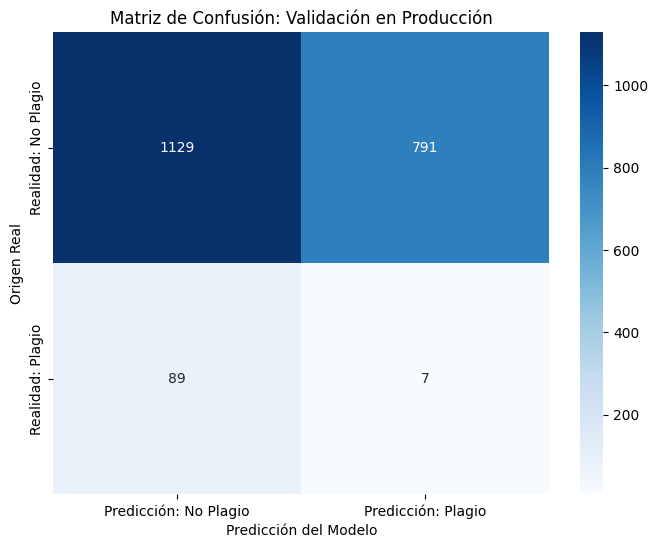


             PERFORMANCE BY OBFUSCATION LEVEL


/tmp/ipykernel_24/3889839038.py:117: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  level_stats = plagiarism_pairs_copy.groupby('Pair_Level').apply(


,Total Pairs,Correctly Flagged,Missed (False Negatives),Accuracy (%)
Pair_Level,,,,
l1,32.0,1.0,31.0,3.125000
l2,16.0,1.0,15.0,6.250000
l3,48.0,5.0,43.0,10.416667



                  MISCLASSIFIED INSTANCES


,File_1,File_2,Level_1,Level_2,Production_Validation,Plagiarism_Probability,Predicted_Class
292,perborgen_linear.py,deepseek_code_l3_barulalithb.py,original,l3,0,0.974350,1
108,deepseek_code_l3_sarvasvkulpati.py,ArayikKarapetyan_linear_regression.py,l3,original,0,0.972529,1
93,deepseek_code_l3_sarvasvkulpati.py,0xHadyy_Linear_Regression_Implementation.py,l3,original,0,0.972275,1
83,deepseek_code_l3_sarvasvkulpati.py,deepseek_code_l1_OmarWill1.py,l3,l1,0,0.972085,1
92,deepseek_code_l3_sarvasvkulpati.py,OmarWill1_linearRegression.py,l3,original,0,0.972085,1
...,...,...,...,...,...,...,...
1914,deepseek_code_l3_oscarbiggins.py,oscarbiggins_linear_regression_scratch.py,l3,original,1,0.298118,0
623,deepseek_code_l1_oscarbiggins.py,deepseek_code_l3_oscarbiggins.py,l1,l3,1,0.298076,0
1791,deepseek_code_l2_oscarbiggins.py,deepseek_code_l3_oscarbiggins.py,l2,l3,1,0.298076,0
687,deepseek_code_l1_l0stinfr0st.py,deepseek_code_l3_l0stinfr0st.py,l1,l3,1,0.296620,0


In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# =============================================================================
# 13. PRODUCTION VALIDATION: EVALUATING MODEL ACCURACY ON REAL DATA
# =============================================================================

def extract_author(filename):
    basename = os.path.basename(filename)
    
    # Handle AI obfuscated files: deepseek_code_l1_AuthorName.py
    if basename.startswith('deepseek_code_'):
        # Remove 'deepseek_code_' -> 'l1_AuthorName.py'
        # Split by the first underscore -> ['l1', 'AuthorName.py']
        parts = basename.replace('deepseek_code_', '').split('_', 1)
        if len(parts) == 2:
            return parts[1].replace('.py', '')
        return basename.replace('.py', '') # Fallback
        
    # Handle original files: AuthorName_RestOfFileName.py
    else:
        # Ignore main.py or generic files safely
        if '_' not in basename:
            return basename.replace('.py', '')
        return basename.split('_')[0].replace('.py', '')

def extract_level(filename):
    basename = os.path.basename(filename)
    if basename.startswith('deepseek_code_'):
        parts = basename.replace('deepseek_code_', '').split('_', 1)
        if len(parts) == 2:
            return parts[0] # Returns 'l1', 'l2', or 'l3'
    return 'original'

# Extract Authors
final_results_df['Author_1'] = final_results_df['File_1'].apply(extract_author)
final_results_df['Author_2'] = final_results_df['File_2'].apply(extract_author)

# Extract Obfuscation Levels
final_results_df['Level_1'] = final_results_df['File_1'].apply(extract_level)
final_results_df['Level_2'] = final_results_df['File_2'].apply(extract_level)

# Ground Truth: If authors match, it is the same codebase (plagiarism)
final_results_df['Production_Validation'] = (final_results_df['Author_1'] == final_results_df['Author_2']).astype(int)

y_true = final_results_df['Production_Validation']
y_pred = final_results_df['Predicted_Class']

# Force a 2x2 matrix using labels=[0, 1] to prevent 1x1 matrix errors
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
total_pairs = len(final_results_df)

tn, fp, fn, tp = cm.ravel()

tp_pct = (tp / total_pairs) * 100 if total_pairs > 0 else 0.0
tn_pct = (tn / total_pairs) * 100 if total_pairs > 0 else 0.0
fp_pct = (fp / total_pairs) * 100 if total_pairs > 0 else 0.0
fn_pct = (fn / total_pairs) * 100 if total_pairs > 0 else 0.0

print("============================================================")
print("             PRODUCTION VALIDATION RESULTS")
print("============================================================\n")

print(f"Total pairs evaluated: {total_pairs}\n")

print(f"True Positives (Correctly identified plagiarism):      {tp} ({tp_pct:.2f}%)")
print(f"True Negatives (Correctly identified unrelated code):  {tn} ({tn_pct:.2f}%)")
print(f"False Positives (Incorrectly flagged as plagiarism):   {fp} ({fp_pct:.2f}%)")
print(f"False Negatives (Missed plagiarism):                   {fn} ({fn_pct:.2f}%)\n")

print("---------------- Classification Report ----------------\n")
try:
    print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Not Plagiarism (0)", "Plagiarism (1)"], zero_division=0))
except ValueError as e:
    print(f"Could not generate classification report: {e}")

# Visualizing Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Predicción: No Plagio', 'Predicción: Plagio'],
            yticklabels=['Realidad: No Plagio', 'Realidad: Plagio'])

plt.title('Matriz de Confusión: Validación en Producción')
plt.ylabel('Origen Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# =============================================================================
# EVALUATION BY OBFUSCATION LEVEL
# =============================================================================
print("\n============================================================")
print("             PERFORMANCE BY OBFUSCATION LEVEL")
print("============================================================")

# Filter for instances where we are comparing an original file to an AI file of the same author
plagiarism_pairs = final_results_df[final_results_df['Production_Validation'] == 1]

if not plagiarism_pairs.empty:
    # Determine the target obfuscation level of the pair
    def determine_pair_level(row):
        levels = {row['Level_1'], row['Level_2']}
        levels.discard('original')
        if not levels:
            return 'original vs original'
        return list(levels)[0]

    plagiarism_pairs_copy = plagiarism_pairs.copy()
    plagiarism_pairs_copy['Pair_Level'] = plagiarism_pairs_copy.apply(determine_pair_level, axis=1)

    # Group by level and calculate accuracy (Recall / True Positive Rate for that level)
    level_stats = plagiarism_pairs_copy.groupby('Pair_Level').apply(
        lambda x: pd.Series({
            'Total Pairs': len(x),
            'Correctly Flagged': x['Predicted_Class'].sum(),
            'Missed (False Negatives)': len(x) - x['Predicted_Class'].sum(),
            'Accuracy (%)': (x['Predicted_Class'].sum() / len(x)) * 100
        })
    )
    display(level_stats)
else:
    print("No valid plagiarism pairs found in the dataset to calculate level metrics.")

# =============================================================================
# MISCLASSIFIED INSTANCES
# =============================================================================
misclassified = final_results_df[final_results_df['Production_Validation'] != final_results_df['Predicted_Class']]

if not misclassified.empty:
    print("\n============================================================")
    print("                  MISCLASSIFIED INSTANCES")
    print("============================================================")
    display_cols = ['File_1', 'File_2', 'Level_1', 'Level_2', 'Production_Validation', 'Plagiarism_Probability', 'Predicted_Class']
    display(misclassified.sort_values(by='Plagiarism_Probability', ascending=False)[display_cols])
else:
    print("\nPerfect accuracy! No misclassified instances found.")